# Z3 PHYSICAL (non-PRS) 5-seed statistical $\beta_N$ scan --- analysis

Scan directory `scan_z3_phys_stat/`: **physical EOM (`prsWall = false`)**, $\mu=0.07$,
$N=512$, **per-$\beta$ box** (each run sized so it ends at exactly 2 comoving horizons per
side), $\beta_N\in\{0.1,0.3,0.5,0.7,0.9\}$, **5 seeds per $\beta_N$** (25 runs). Seeds are
**paired** (common random numbers) with the PRS stat scan `scan_z3_prs_stat/`.

**Why this scan exists:** the PRS method appears *not* to scale, while single-realization
*physical* runs look like they do --- but a single seed cannot beat cosmic (sample)
variance. This is the statistical **physical twin** of the PRS scan (same $\beta_N$ grid,
identical couplings, PRS turned off) to settle whether the *physical* wall network reaches
scaling. Z3 has **only one wall type** (single topological charge step), so there is no
$\mathcal{A}_2$.

**RAW units --- $\mu\neq 1$ rescales the radial markers (key difference from the PRS
notebooks):** `average_scalar` is in raw field units, so the broken vacuum sits at
$\langle|\Phi|^2\rangle = v^2/2 = \mu^2/2 = 0.00245$ **(not 0.5)** and the breaking marker
is $\mu^2/4 = 0.001225$ **(not 0.25)**. Formation is **late** ($a_{\rm form}\sim16$--$22$)
because the tachyonic drive $\propto\mu^2$; with $H_0/\mu=1$ the background is $a=1+\eta$.

**Per-$\beta$ box (variable $L$).** Each $\beta$ has its own $L$, sized by
`gen_phys_stat_cards.py`: $a_{\max}=\sqrt{\bar\delta\,N/(\mu\,n_{\rm res}\,h_{\rm min})}$,
$L=h_{\rm min}a_{\max}$, $n_{\rm res}=1$, $h_{\rm min}=2$ --- so **every run ends at exactly
2 horizons/side**.

**Scaling convention (do not use raw `scal`):**
$$\mathcal{A}_1 \equiv \frac{\mathrm{scal}_1}{2aH},$$
with $a,H$ from `average_scale_factor.txt` (**column 1 ($a$), column 3 ($H$)**, not column 2
($a'$)). `average_energies.txt` has **10 columns**:
`[eta, Ek1, Ek2, Eg1, Eg2, Ev1, Ev2, Ev3, Etot, scal1]`, i.e. `scal1` is the last
(index 9) column.

**Breaking criterion:** $\langle|\Phi|^2\rangle>\mu^2/4$ (first crossing). Do **not** use
$E_{V_1}<0$ for Z3: the vacuum-energy offset $V_0$ is $\beta_N$-dependent (for $\beta_N=0.9$
$E_{V_1}$ can stay positive even when broken).

**Cross-$\beta$ comparison = equal-horizon / own-end.** $\S 8$ (in-window slope) and $\S 9$
(plateau) measure each $\beta$ at its **own** 2-horizon end, not at a shared $\eta$.

In [52]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

# Set True for the paper LaTeX style (requires a local LaTeX install); False lets this
# notebook execute anywhere (e.g. CI / headless nodes without latex).
USETEX = True
rc('text', usetex=USETEX)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

## Configuration

In [53]:
BASE = '/mt/user-batch/dpasari/scan_z3_phys_stat/'

MU      = 0.07
N       = 512
N_SEEDS = 5
N_RES   = 1.0      # cells/wall required at a_max (box-sizing target)
H_MIN   = 2.0      # horizons/side required at a_max

BETAS = [0.1, 0.3, 0.5, 0.7, 0.9]
BLAB  = {0.1: '1', 0.3: '3', 0.5: '5', 0.7: '7', 0.9: '9'}

# RAW-units radial markers (mu != 1): vacuum <|Phi|^2> = mu^2/2, breaking marker = mu^2/4
VAC   = MU**2 / 2.0     # 0.002450
BREAK = MU**2 / 4.0     # 0.001225

# dimensionless BVP wall widths (delta_bar); Z3 has only adjacent walls.
D_ADJ = {0.1: 2.657, 0.3: 1.55, 0.5: 1.243, 0.7: 1.059, 0.9: 0.843}

# Per-beta box (same sizer as gen_phys_stat_cards.py). a = 1+eta (H0/mu = 1).
def _amax(b):
    return math.sqrt(D_ADJ[b] * N / (MU * N_RES * H_MIN))
A_MAX = {b: _amax(b)        for b in BETAS}
L     = {b: H_MIN * A_MAX[b] for b in BETAS}
DX    = {b: L[b] / N         for b in BETAS}
TMAX  = {b: A_MAX[b] - 1.0   for b in BETAS}

_CMAP = plt.cm.winter
COLOR = {b: _CMAP((b - 0.1) / 0.8) for b in BETAS}
LABEL = {b: rf'$\beta_N={b}$' for b in BETAS}

def config_handles(betas):
    return [Line2D([0], [0], color=COLOR[b], lw=2.4, ls='solid', label=LABEL[b])
            for b in betas]

def add_legend(ax, betas, **kw):
    kw.setdefault('fontsize', 13)
    kw.setdefault('frameon', False)
    kw.setdefault('loc', 'upper left')
    kw.setdefault('bbox_to_anchor', (1.02, 1.0))
    kw.setdefault('borderaxespad', 0)
    ax.legend(handles=config_handles(betas), **kw)

def run_dir(beta, seed):
    return os.path.join(BASE, f'results_DWZ3_physstat_b30p{BLAB[beta]}_s{seed:02d}')

# Sizing sanity table: cells/wall (start a=1 vs end a=a_max) and the per-beta box.
print(f"{'betaN':>6s} {'L':>8s} {'dx':>7s} {'a_max':>7s} {'adj@1':>8s}"
      f" {'adj@end':>8s} {'hor@end':>8s}")
print('-' * 56)
for b in BETAS:
    adj_start = D_ADJ[b] / (MU * 1.0 * DX[b])
    adj_end   = D_ADJ[b] / (MU * A_MAX[b] * DX[b])
    print(f"{b:>6.1f} {L[b]:>8.1f} {DX[b]:>7.3f} {A_MAX[b]:>7.1f} {adj_start:>8.1f}"
          f" {adj_end:>8.2f} {H_MIN:>8.1f}")

 betaN        L      dx   a_max    adj@1  adj@end  hor@end
--------------------------------------------------------
   0.1    197.1   0.385    98.6     98.6     1.00      2.0
   0.3    150.6   0.294    75.3     75.3     1.00      2.0
   0.5    134.8   0.263    67.4     67.4     1.00      2.0
   0.7    124.5   0.243    62.2     62.2     1.00      2.0
   0.9    111.0   0.217    55.5     55.5     1.00      2.0


## Loaders

Per-(`beta`,`seed`) loader returns the data products or `None` if any file is
missing/empty/too-short (`plot-if-ran`: missing seeds are silently skipped downstream).

In [54]:
def load_energies(path):
    # Z3: 10 cols -- eta,Ek1,Ek2,Eg1,Eg2,Ev1,Ev2,Ev3,Etot,scal1 (last col, no scal2)
    data = _safe_loadtxt(os.path.join(path, 'average_energies.txt'))
    if data is None or data.shape[1] < 10:
        return None
    return {
        'eta':   data[:, 0], 'Ek_1': data[:, 1], 'Ek_2': data[:, 2],
        'Eg_1':  data[:, 3], 'Eg_2': data[:, 4], 'Ev_1': data[:, 5],
        'Ev_2':  data[:, 6], 'Ev_3': data[:, 7], 'E_tot': data[:, 8],
        'scal1': data[:, 9],
    }


def _safe_loadtxt(fpath):
    try:
        if not os.path.exists(fpath) or os.path.getsize(fpath) == 0:
            return None
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError, ValueError, StopIteration):
        return None
    if data.size == 0:
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return data


def load_scalar(path, idx):
    data = _safe_loadtxt(os.path.join(path, f'average_scalar_{idx}.txt'))
    if data is None or data.shape[1] < 6:
        return None
    return {
        'eta': data[:, 0], 'phi': data[:, 1], 'phi_prime': data[:, 2],
        'phi2': data[:, 3], 'phi_prime2': data[:, 4], 'rms_phi': data[:, 5],
    }


def load_scale_factor(path):
    # Cols: eta, a, a', H -- use a=col1, H=col3 (NOT a'=col2)
    data = _safe_loadtxt(os.path.join(path, 'average_scale_factor.txt'))
    if data is None or data.shape[1] < 4:
        return None
    return {'eta': data[:, 0], 'a': data[:, 1], 'aprime': data[:, 2], 'H': data[:, 3]}


def load_run(beta, seed):
    path = run_dir(beta, seed)
    en = load_energies(path)
    sf = load_scale_factor(path)
    s0 = load_scalar(path, 0)
    s1 = load_scalar(path, 1)
    if any(x is None for x in [en, sf, s0, s1]):
        return None
    if len(en['eta']) < 2 or len(sf['eta']) < 2:
        return None
    return {'beta': beta, 'seed': seed, 'energies': en, 'scale_factor': sf,
            'scalar_0': s0, 'scalar_1': s1}

## Load all runs

Discovery: how many of the 5 seeds are present per $\beta$, and how far each ran (the
planned end is each $\beta$'s 2-horizon $\eta$).

In [55]:
# Discovery: how many of the 5 seeds are present per beta, and their last eta.
RUNS = {}
print(f"{'beta':>6s} {'n_seeds':>8s} {'last_eta (per seed)'}")
print('-' * 90)
for b in BETAS:
    runs = {}
    last_etas = []
    for s in range(1, N_SEEDS + 1):
        r = load_run(b, s)
        if r is not None:
            runs[s] = r
            last_etas.append(r['energies']['eta'][-1])
    RUNS[b] = runs
    last_str = ', '.join(f'{x:.1f}' for x in last_etas)
    print(f"{b:>6.1f} {len(runs):>8d}   [{last_str}]  (planned end {TMAX[b]:.1f})")

  beta  n_seeds last_eta (per seed)
------------------------------------------------------------------------------------------
   0.1        5   [97.5, 97.5, 97.5, 97.5, 97.5]  (planned end 97.6)
   0.3        5   [74.2, 74.2, 74.2, 74.2, 74.2]  (planned end 74.3)
   0.5        5   [66.4, 66.4, 66.4, 66.4, 66.4]  (planned end 66.4)
   0.7        5   [61.2, 61.2, 61.2, 61.2, 61.2]  (planned end 61.2)
   0.9        5   [54.5, 54.5, 54.5, 54.5, 54.5]  (planned end 54.5)


## Plot helpers

In [56]:
def paper_ax(ax, xlabel=r'$\eta$', ylabel='', title=''):
    ax.set_xlabel(xlabel, fontsize=24)
    if ylabel: ax.set_ylabel(ylabel, fontsize=24)
    if title:  ax.set_title(title,   fontsize=20)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=18, pad=6)
    ax.tick_params(which='major', length=9)
    ax.tick_params(which='minor', length=4)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)


def phi2_radial(run):
    # <|Phi|^2> = (phi2 of field 0 + phi2 of field 1) / 2; RAW units (vacuum = mu^2/2)
    s0, s1 = run['scalar_0'], run['scalar_1']
    n = min(len(s0['eta']), len(s1['eta']))
    return s0['eta'][:n], (s0['phi2'][:n] + s1['phi2'][:n]) / 2.0


def breaking_onset_eta(run):
    # FORMATION onset = the turnaround (minimum) of <|Phi|^2>. The raw initial fluctuations
    # are NOT mu^2-scaled (p2 starts ~0.1 >> vacuum mu^2/2), decay ~1/a^2 to a minimum near
    # a ~ 14-16, then the tachyonic instability grows p2 back up to the broken vacuum mu^2/2.
    # A plain threshold crossing fails (p2 starts far above mu^2/4), so use the interior min.
    eta, p2 = phi2_radial(run)
    if eta.size < 5:
        return None
    i = int(np.argmin(p2))
    if i == 0 or i >= len(p2) - 1:   # no interior turnaround yet -> not formed
        return None
    return float(eta[i])


def local_logslope(x, y, nbin=60):
    # d ln y / d ln x on coarse log-spaced bins (noise-robust)
    m = (x > 0) & (y > 0) & np.isfinite(y)
    if m.sum() < 10:
        return np.array([]), np.array([])
    lx, ly = np.log(x[m]), np.log(y[m])
    edges = np.linspace(lx[0], lx[-1], nbin + 1)
    idx = np.digitize(lx, edges)
    bx, by = [], []
    for i in range(1, nbin + 1):
        sel = idx == i
        if sel.sum() > 0:
            bx.append(lx[sel].mean()); by.append(ly[sel].mean())
    bx, by = np.array(bx), np.array(by)
    if len(bx) < 4:
        return np.array([]), np.array([])
    return np.exp(0.5*(bx[1:] + bx[:-1])), np.diff(by)/np.diff(bx)


def horizon_guide_end(ax, beta):
    # each run ENDS at exactly H_MIN horizons/side; mark that eta (per beta) faintly
    eta_end = L[beta] / H_MIN - 1.0
    ax.axvline(eta_end, color=COLOR[beta], ls=':', lw=0.9, alpha=0.35)


def area_param(run):
    # A1 = scal1 / (2 a H) vs eta; a,H interpolated from the scale-factor file
    en, sf = run['energies'], run['scale_factor']
    a_arr = np.interp(en['eta'], sf['eta'], sf['a'])
    H_arr = np.interp(en['eta'], sf['eta'], sf['H'])
    with np.errstate(divide='ignore', invalid='ignore'):
        A = en['scal1'] / (2.0 * a_arr * H_arr)
    return en['eta'], A

## Seed-aggregation helper

`seed_mean_std(beta, quantity_fn)`: for each available seed compute
`quantity_fn(run) -> (eta, y)`, interpolate every seed onto a common $\eta$ grid, and
return the across-seed mean and std (NaN-tolerant of partial coverage).

In [57]:
def seed_mean_std(beta, quantity_fn, n_grid=400):
    runs = RUNS.get(beta, {})
    curves = []
    eta_lo, eta_hi = None, None
    for s, run in runs.items():
        try:
            eta, y = quantity_fn(run)
        except Exception:
            continue
        eta = np.asarray(eta); y = np.asarray(y)
        if eta.size < 2:
            continue
        curves.append((eta, y))
        lo, hi = eta[0], eta[-1]
        eta_lo = lo if eta_lo is None else min(eta_lo, lo)
        eta_hi = hi if eta_hi is None else max(eta_hi, hi)
    if not curves or eta_lo is None or eta_hi <= eta_lo:
        return np.array([]), np.array([]), np.array([]), 0

    eta_grid = np.linspace(eta_lo, eta_hi, n_grid)
    stacked = np.full((len(curves), n_grid), np.nan)
    for i, (eta, y) in enumerate(curves):
        # only interpolate within this seed's own eta-range; outside -> NaN
        in_range = (eta_grid >= eta[0]) & (eta_grid <= eta[-1])
        stacked[i, in_range] = np.interp(eta_grid[in_range], eta, y)

    mean = np.nanmean(stacked, axis=0)
    std  = np.nanstd(stacked, axis=0)
    return eta_grid, mean, std, len(curves)

## 1. Health: radial diagnostic $\langle|\Phi|^2\rangle$ and mean-field drift

**Left (log-$y$):** $\langle|\Phi|^2\rangle=(\langle h^2\rangle+\langle a^2\rangle)/2$. The
raw initial fluctuations start far above the vacuum ($\sim0.1\gg\mu^2/2$), decay
$\sim1/a^2$ to a **minimum near $a\sim14$--$16$ --- the formation onset (turnaround)** ---
then the tachyonic instability ($\propto\mu^2$) grows them back up to the broken vacuum
$\mu^2/2$ (solid guide; dashed $=\mu^2/4$).

**Right:** $|\langle\Phi\rangle|=\sqrt{\langle h\rangle^2+\langle a\rangle^2}$; growth
toward $\mathcal{O}(\mu)$ (faint guide) signals finite-volume domain depletion.

Each curve is the across-seed mean; the shaded band is $\pm1\sigma$ across seeds.

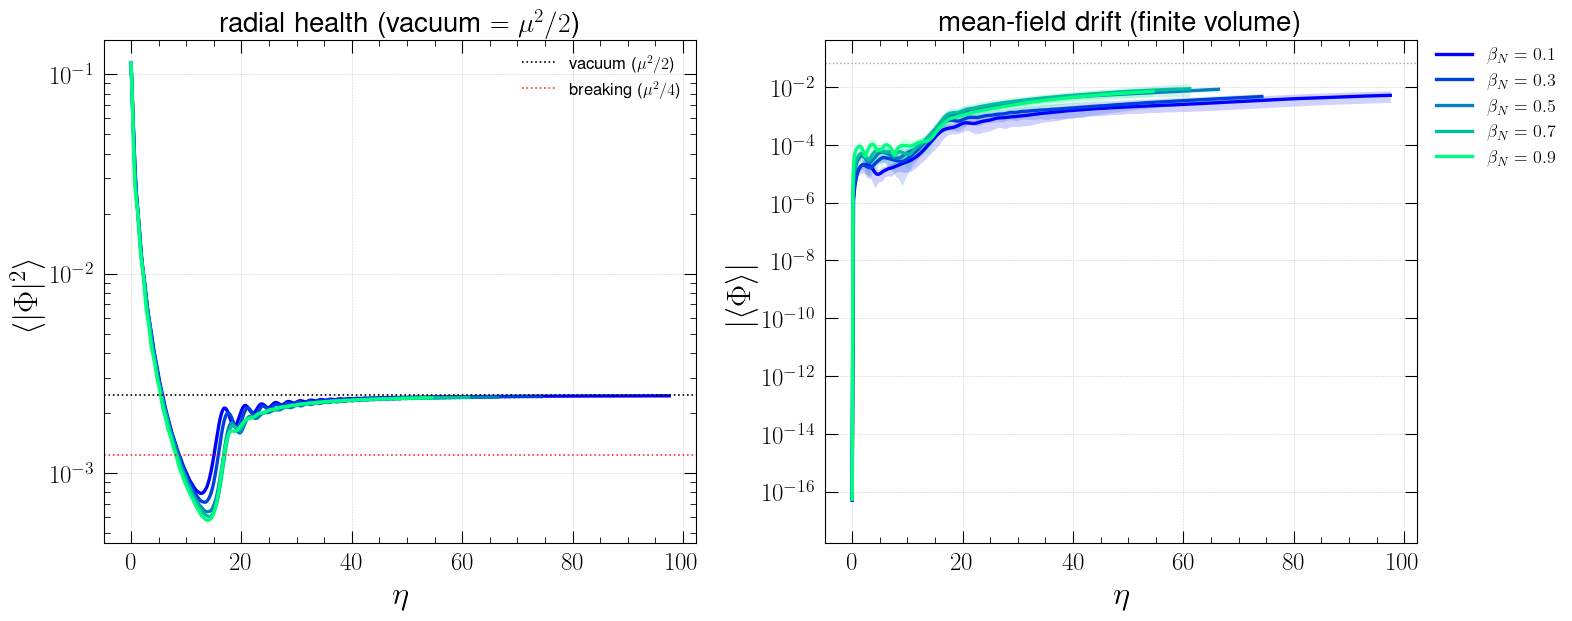

In [58]:
def drift_curve(run):
    # |<Phi>| = sqrt(<h>^2 + <a>^2); field 1 interpolated onto field 0's eta (-> O(mu) on depletion)
    s0, s1 = run['scalar_0'], run['scalar_1']
    n = min(len(s0['eta']), len(s1['eta']))
    eta = s0['eta'][:n]
    phi1 = np.interp(eta, s1['eta'], s1['phi'])
    return eta, np.sqrt(s0['phi'][:n]**2 + phi1**2)


fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, phi2_radial)
    if eta.size:
        axes[0].plot(eta, mean, color=COLOR[b], lw=2.4)
        axes[0].fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)
    etad, meand, stdd, nd = seed_mean_std(b, drift_curve)
    if etad.size:
        axes[1].plot(etad, meand, color=COLOR[b], lw=2.4)
        axes[1].fill_between(etad, meand - stdd, meand + stdd, color=COLOR[b], alpha=0.18, lw=0)

axes[0].axhline(VAC,   color='k', ls=':', lw=1.2, label=r'vacuum ($\mu^2/2$)')
axes[0].axhline(BREAK, color='r', ls=':', lw=1.2, alpha=0.8, label=r'breaking ($\mu^2/4$)')
axes[0].legend(fontsize=12, frameon=False)
axes[0].set_yscale('log')   # initial fluct (~0.1) dwarf the vacuum (mu^2/2); log shows the dip-and-rise
axes[1].axhline(MU, color='gray', ls=':', lw=1.0, alpha=0.7)
axes[1].set_yscale('log')
paper_ax(axes[0], ylabel=r'$\langle|\Phi|^2\rangle$',
         title=r'radial health (vacuum $=\mu^2/2$)')
paper_ax(axes[1], ylabel=r'$|\langle\Phi\rangle|$',
         title=r'mean-field drift (finite volume)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 2. Potential energies $E_{V_1}$, $E_{V_2}$, $E_{V_3}$

$E_{V_1}=-\mu^2\langle|\Phi|^2\rangle + V_0$ with a $\beta$-dependent vacuum offset $V_0$,
so $E_{V_1}$ can stay positive even in the broken vacuum (e.g. $\beta=0.9$). Use the
$\langle|\Phi|^2\rangle>\mu^2/4$ marker for breaking, **not** the sign of $E_{V_1}$. Right
panel: quartic terms (solid $E_{V_2}$, dashed $E_{V_3}$). Bands are seed $\pm1\sigma$.

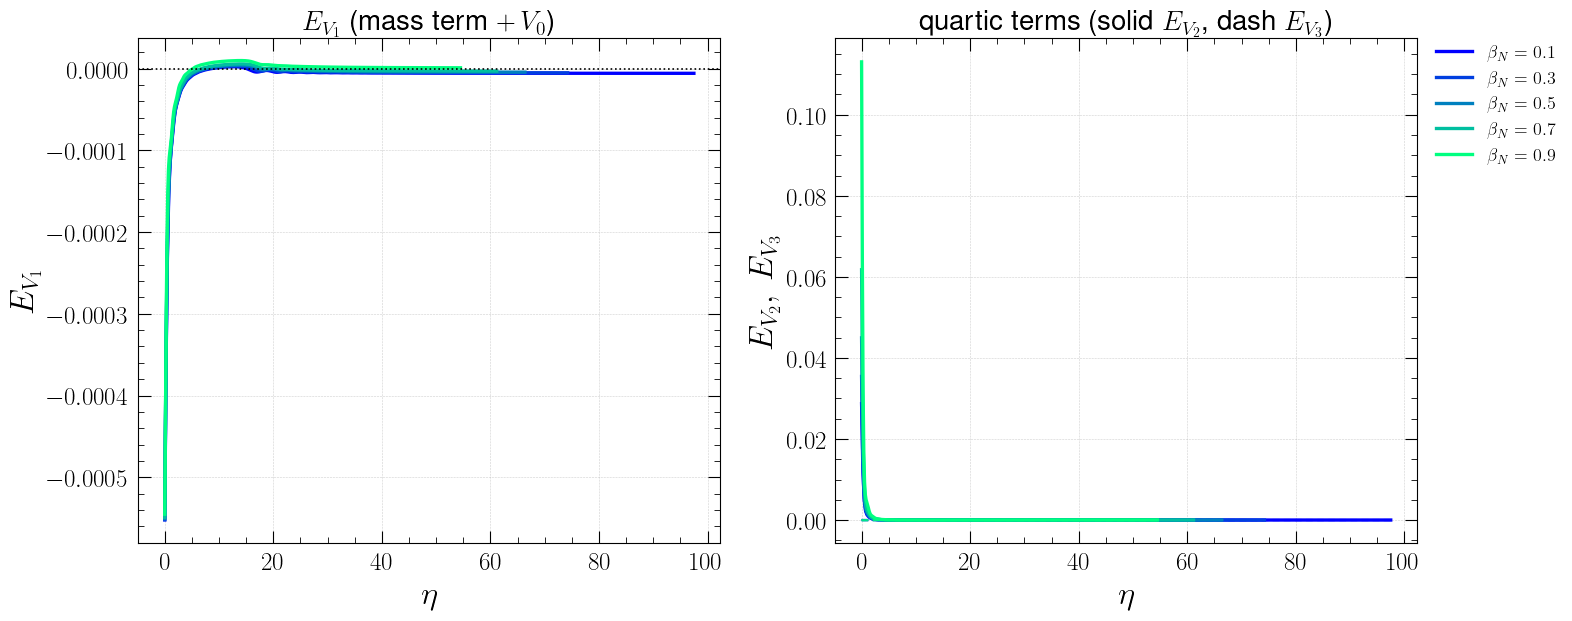

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    e1, m1, s1, _ = seed_mean_std(b, lambda r: (r['energies']['eta'], r['energies']['Ev_1']))
    if e1.size:
        axes[0].plot(e1, m1, color=COLOR[b], lw=2.4)
        axes[0].fill_between(e1, m1 - s1, m1 + s1, color=COLOR[b], alpha=0.18, lw=0)
    e2, m2, s2, _ = seed_mean_std(b, lambda r: (r['energies']['eta'], r['energies']['Ev_2']))
    if e2.size:
        axes[1].plot(e2, m2, color=COLOR[b], lw=2.4)
        axes[1].fill_between(e2, m2 - s2, m2 + s2, color=COLOR[b], alpha=0.18, lw=0)
    e3, m3, s3, _ = seed_mean_std(b, lambda r: (r['energies']['eta'], r['energies']['Ev_3']))
    if e3.size:
        axes[1].plot(e3, m3, color=COLOR[b], ls=(0, (3, 2)), lw=1.6, alpha=0.7)

axes[0].axhline(0, color='k', ls=':', lw=1.2)
paper_ax(axes[0], ylabel=r'$E_{V_1}$', title=r'$E_{V_1}$ (mass term $+\,V_0$)')
paper_ax(axes[1], ylabel=r'$E_{V_2},\;E_{V_3}$',
         title=r'quartic terms (solid $E_{V_2}$, dash $E_{V_3}$)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 3. Kinetic and gradient energies

Both scalar components summed; log--log. Seed mean $\pm1\sigma$ band per $\beta$.

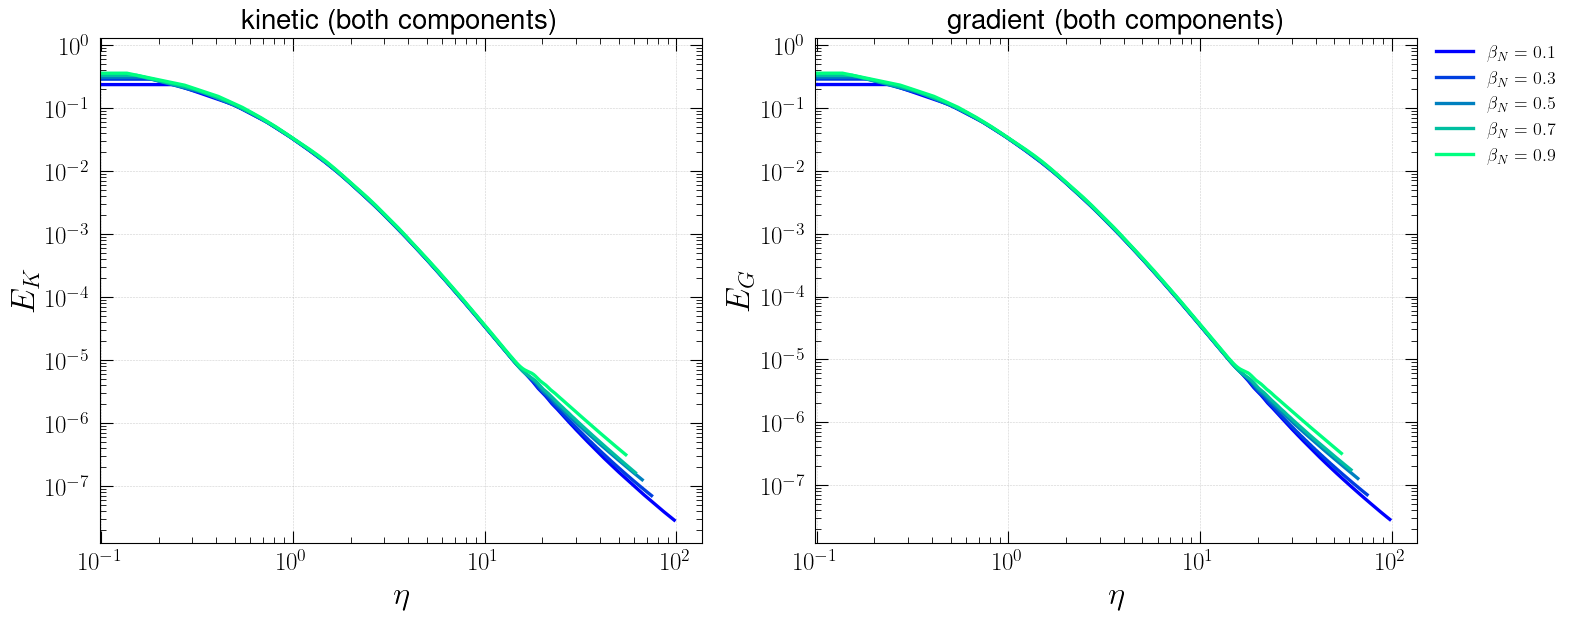

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    ek, mk, sk, _ = seed_mean_std(
        b, lambda r: (r['energies']['eta'], r['energies']['Ek_1'] + r['energies']['Ek_2']))
    if ek.size:
        axes[0].plot(ek, mk, color=COLOR[b], lw=2.4)
        axes[0].fill_between(ek, np.clip(mk - sk, 1e-30, None), mk + sk,
                             color=COLOR[b], alpha=0.18, lw=0)
    eg, mg, sg, _ = seed_mean_std(
        b, lambda r: (r['energies']['eta'], r['energies']['Eg_1'] + r['energies']['Eg_2']))
    if eg.size:
        axes[1].plot(eg, mg, color=COLOR[b], lw=2.4)
        axes[1].fill_between(eg, np.clip(mg - sg, 1e-30, None), mg + sg,
                             color=COLOR[b], alpha=0.18, lw=0)

for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
paper_ax(axes[0], ylabel=r'$E_K$', title=r'kinetic (both components)')
paper_ax(axes[1], ylabel=r'$E_G$', title=r'gradient (both components)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 4. Scalar-field means $\langle h\rangle$, $\langle a\rangle$

Per-component volume-averaged field. The band is **seed scatter** ($\pm1\sigma$ across
seeds): each seed's mean field drifts to a random sign under finite-volume depletion.

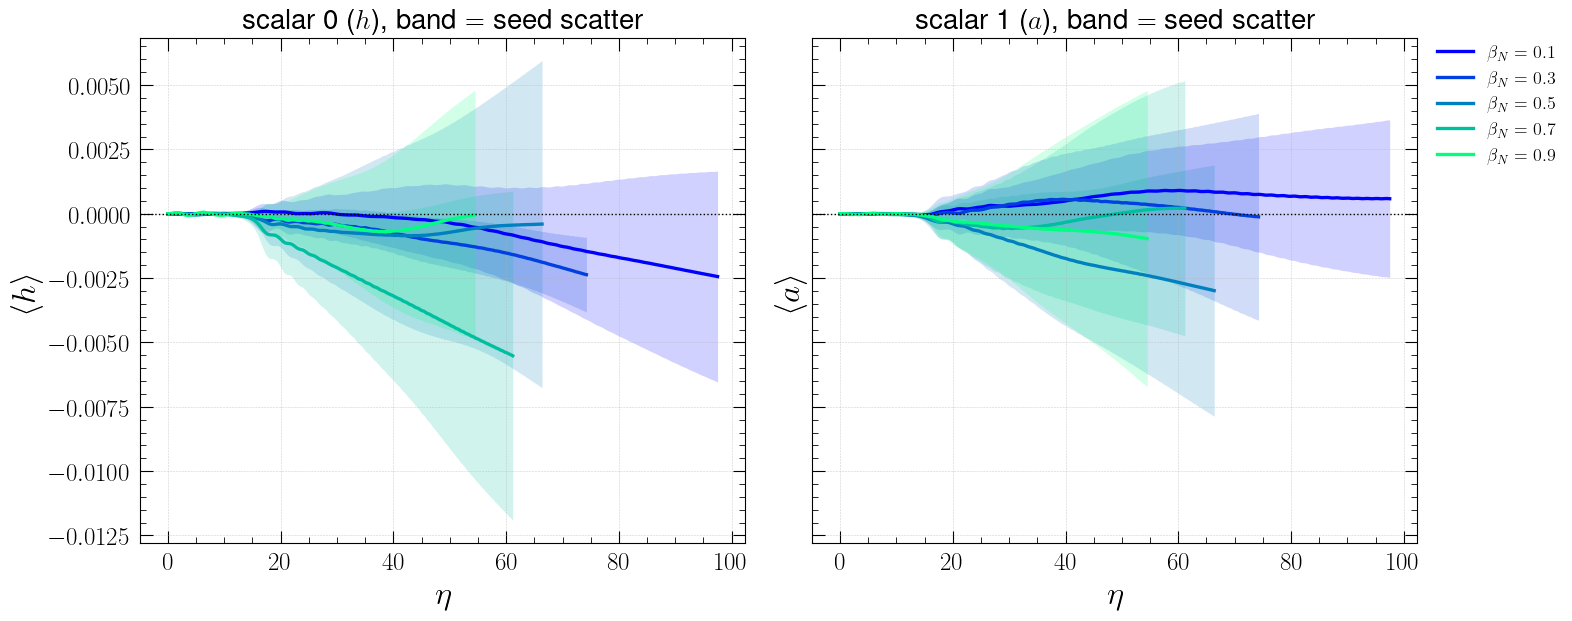

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True, sharey=True)
for b in BETAS:
    eh, mh, sh, _ = seed_mean_std(b, lambda r: (r['scalar_0']['eta'], r['scalar_0']['phi']))
    if eh.size:
        axes[0].plot(eh, mh, color=COLOR[b], lw=2.4)
        axes[0].fill_between(eh, mh - sh, mh + sh, color=COLOR[b], alpha=0.18, lw=0)
    ea, ma, sa, _ = seed_mean_std(b, lambda r: (r['scalar_1']['eta'], r['scalar_1']['phi']))
    if ea.size:
        axes[1].plot(ea, ma, color=COLOR[b], lw=2.4)
        axes[1].fill_between(ea, ma - sa, ma + sa, color=COLOR[b], alpha=0.18, lw=0)

for ax in axes:
    ax.axhline(0, color='k', ls=':', lw=1.0)
paper_ax(axes[0], ylabel=r'$\langle h\rangle$', title=r'scalar 0 ($h$), band $=$ seed scatter')
paper_ax(axes[1], ylabel=r'$\langle a\rangle$', title=r'scalar 1 ($a$), band $=$ seed scatter')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 5. Scale factor and Hubble

Sanity panel: $a(\eta)$ and the conformal Hubble $\mathcal{H}=a'/a$ from
`average_scale_factor.txt`. Fixed radiation background ($H_0=\mu$), identical for every
$\beta$ and seed: $a\approx1+\eta$, $\mathcal{H}\propto1/a$, and $2aH=2a'$ is nearly
constant --- so $\mathcal{A}\equiv\mathrm{scal}/(2aH)$ divides it out exactly.

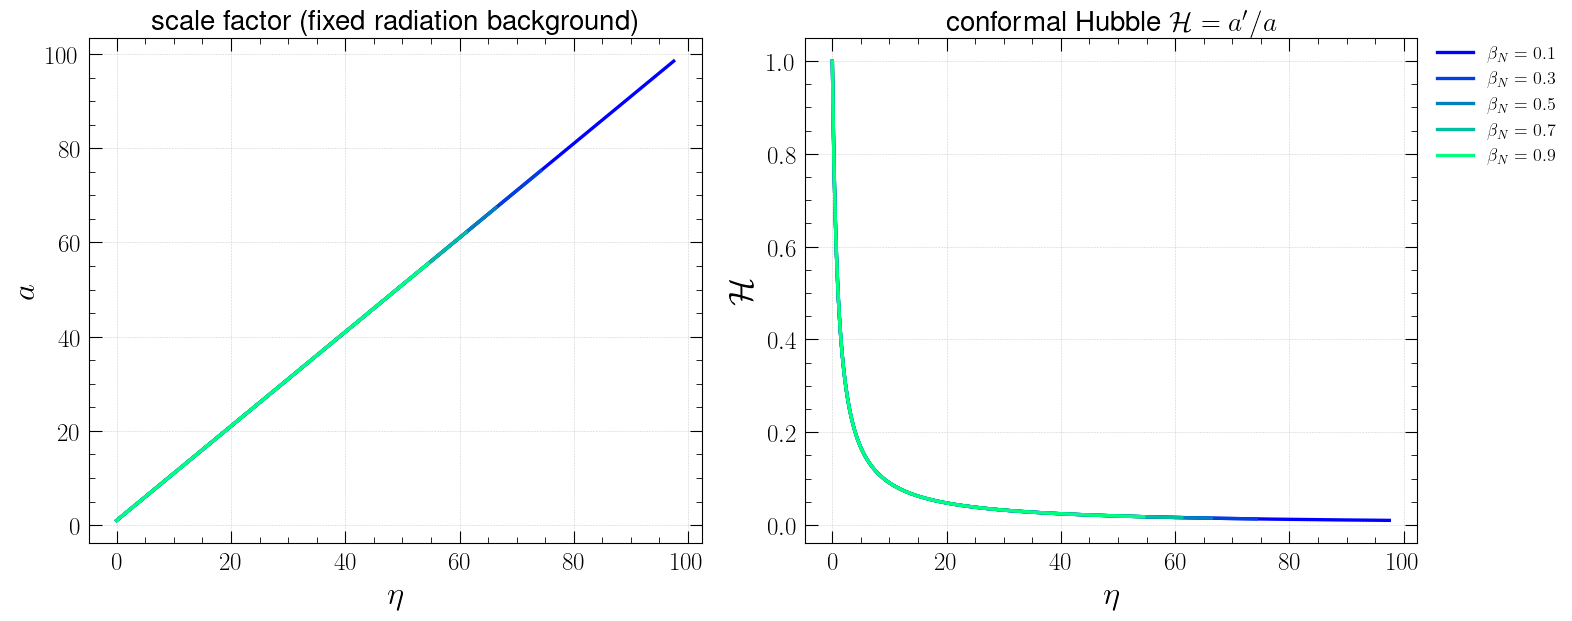

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    ea, ma, sa, _ = seed_mean_std(b, lambda r: (r['scale_factor']['eta'], r['scale_factor']['a']))
    if ea.size:
        axes[0].plot(ea, ma, color=COLOR[b], lw=2.4)
    eh, mh, sh, _ = seed_mean_std(b, lambda r: (r['scale_factor']['eta'], r['scale_factor']['H']))
    if eh.size:
        axes[1].plot(eh, mh, color=COLOR[b], lw=2.4)

paper_ax(axes[0], ylabel=r'$a$', title=r'scale factor (fixed radiation background)')
paper_ax(axes[1], ylabel=r"$\mathcal{H}$", title=r"conformal Hubble $\mathcal{H}=a'/a$")
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 6. Wall-area parameter $\mathcal{A}_1$

$\mathcal{A}_1\equiv\mathrm{scal}_1/(2aH)$. Z3 has only one wall type. Left: linear; right:
log--log (eye-guide for plateau/power-law). Seed mean $\pm1\sigma$; guide at
$\mathcal{A}_1=1$. Faint verticals = each $\beta$'s 2-horizon end (the right endpoint of
each curve).

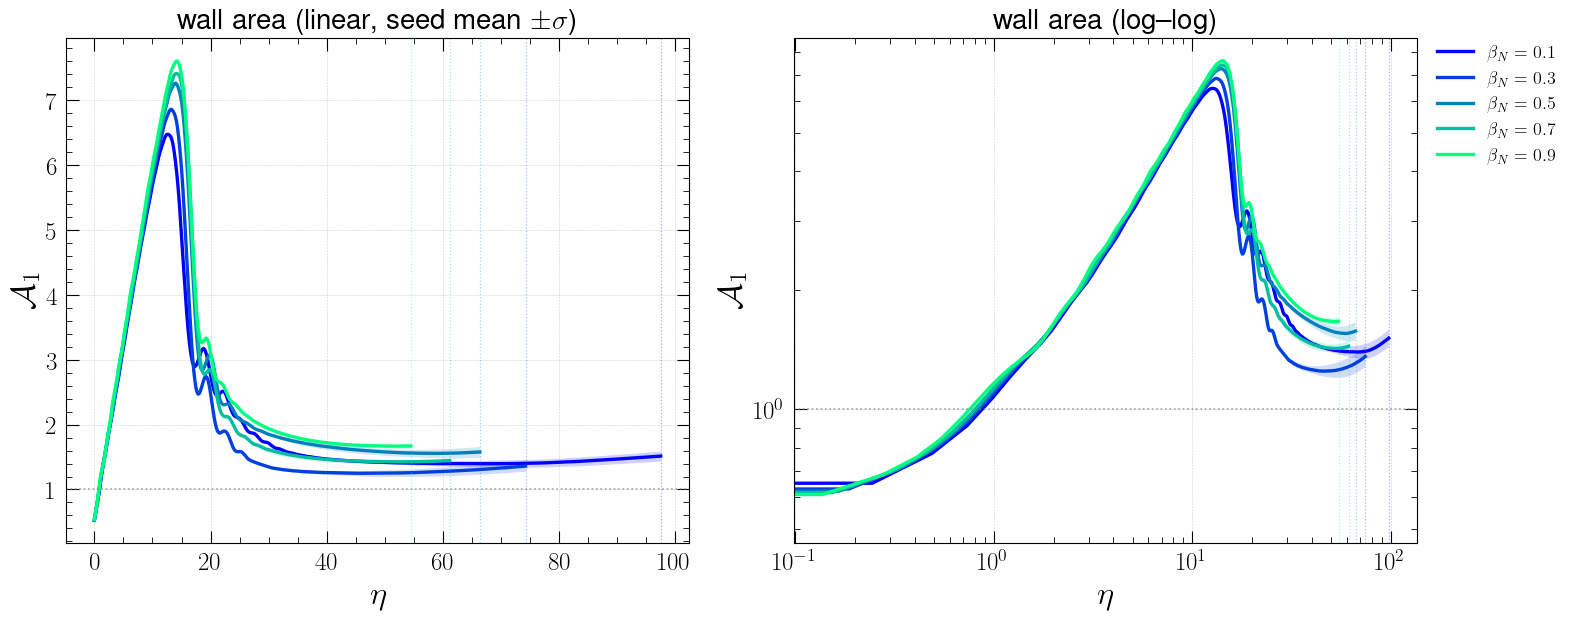

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, area_param)
    if eta.size == 0:
        continue
    axes[0].plot(eta, mean, color=COLOR[b], lw=2.4)
    axes[0].fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)
    axes[1].plot(eta, mean, color=COLOR[b], lw=2.4)
    axes[1].fill_between(eta, np.clip(mean - std, 1e-30, None), mean + std,
                         color=COLOR[b], alpha=0.18, lw=0)
    horizon_guide_end(axes[0], b)
    horizon_guide_end(axes[1], b)

for ax in axes:
    ax.axhline(1.0, color='gray', ls=':', lw=1.2, alpha=0.7)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
paper_ax(axes[0], ylabel=r'$\mathcal{A}_1$', title=r'wall area (linear, seed mean $\pm\sigma$)')
paper_ax(axes[1], ylabel=r'$\mathcal{A}_1$', title=r'wall area (log--log)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, area_param)
    if eta.size == 0:
        continue
    axes[0].plot(eta, mean, color=COLOR[b], lw=2.4)
    axes[0].fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)
    axes[1].plot(eta, mean, color=COLOR[b], lw=2.4)
    axes[1].fill_between(eta, np.clip(mean - std, 1e-30, None), mean + std,
                         color=COLOR[b], alpha=0.18, lw=0)
    horizon_guide_end(axes[0], b)
    horizon_guide_end(axes[1], b)

for ax in axes:
    ax.axhline(1.0, color='gray', ls=':', lw=1.2, alpha=0.7)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
paper_ax(axes[0], ylabel=r'$\mathcal{A}_1$', title=r'wall area (linear, seed mean $\pm\sigma$)')
paper_ax(axes[1], ylabel=r'$\mathcal{A}_1$', title=r'wall area (log--log)')
add_legend(axes[1], BETAS)
plt.tight_layout(); plt.show()

## 7. Local logarithmic slope ${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$

Computed **per seed first** (only $\eta>1.5\,\eta_{\rm break}$ to skip the transient), then
aggregated across seeds. Scaling $\Leftrightarrow$ slope $\to0$ (horizontal guide).

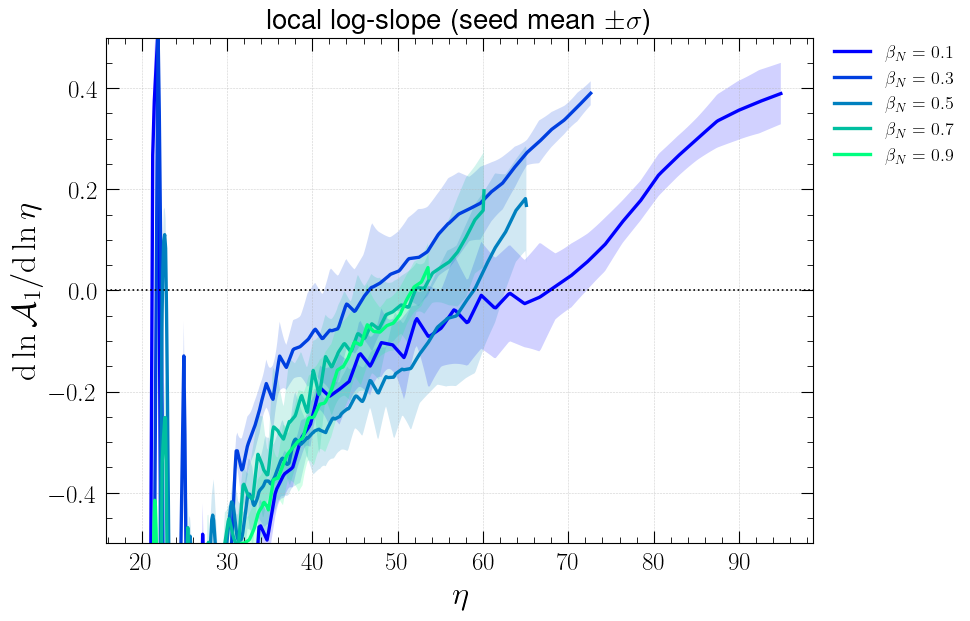

In [64]:
def logslope_curve(run):
    eta, A = area_param(run)
    eb = breaking_onset_eta(run)
    sel = eta > (1.5 * eb if eb is not None else 0)
    return local_logslope(eta[sel], A[sel])


fig, ax = plt.subplots(figsize=(10, 6.5))
for b in BETAS:
    eta, mean, std, n = seed_mean_std(b, logslope_curve)
    if eta.size == 0:
        continue
    ax.plot(eta, mean, color=COLOR[b], lw=2.4)
    ax.fill_between(eta, mean - std, mean + std, color=COLOR[b], alpha=0.18, lw=0)

ax.axhline(0, color='k', ls=':', lw=1.2)
# ax.set_xscale('log')
ax.set_ylim(-0.5,0.5)
paper_ax(ax, ylabel=r'${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$',
         title=r'local log-slope (seed mean $\pm\sigma$)')
add_legend(ax, BETAS)
plt.tight_layout(); plt.show()

## 8. In-window slope vs $\beta$ (equal-horizon / own-end) --- THE key result

Per seed, fit a line to $\ln\mathcal{A}_1$ vs $\ln\eta$ over
$\eta\in[1.5\,\eta_{\rm break},\,\eta_{\rm end}]$, where $\eta_{\rm end}$ is **that run's own
last $\eta$** (its 2-horizon end). Errorbar = across-seed mean $\pm1\sigma$. A slope
consistent with $0$ within error means scaling.

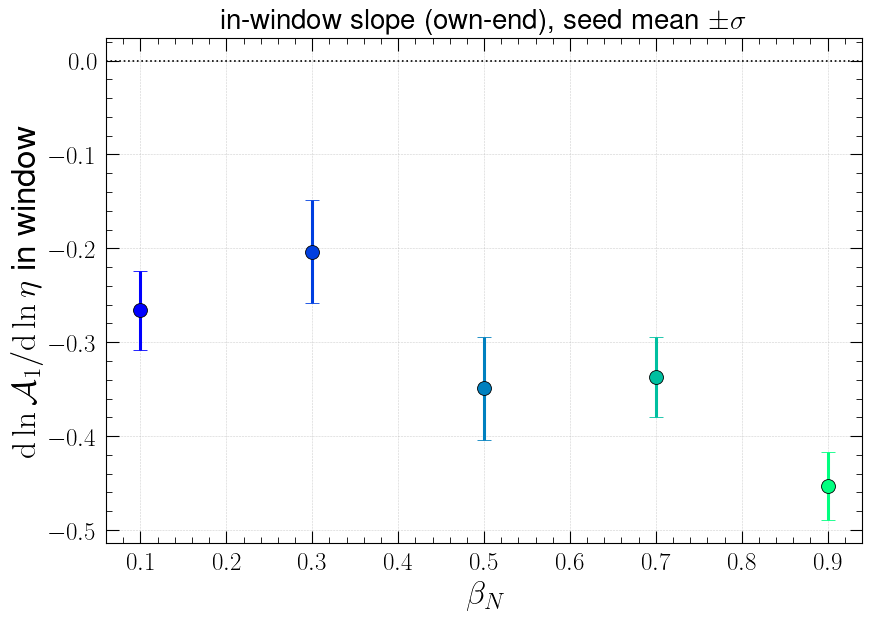

 betaN  n_seeds  slope_mean  slope_std
----------------------------------------
   0.1        5     -0.2659     0.0420
   0.3        5     -0.2037     0.0547
   0.5        5     -0.3488     0.0549
   0.7        5     -0.3373     0.0428
   0.9        5     -0.4532     0.0366


In [65]:
def fit_logslope_window(run):
    eta, A = area_param(run)
    eb = breaking_onset_eta(run)
    lo = 1.5 * eb if eb is not None else (eta[0] if eta.size else 0.0)
    # hi = own end (no cap) -> 2-horizon end; guard eta>0 (no log(0)) and finiteness
    sel = (eta >= lo) & (eta > 0) & (A > 0) & np.isfinite(A) & np.isfinite(eta)
    x = np.log(eta[sel]); y = np.log(A[sel])
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 5 or np.ptp(x) <= 0:
        return np.nan
    return float(np.polyfit(x, y, 1)[0])   # slope of ln A vs ln eta


slope_mean, slope_std, slope_n = {}, {}, {}
for b in BETAS:
    vals = np.array([fit_logslope_window(r) for r in RUNS.get(b, {}).values()])
    vals = vals[np.isfinite(vals)]
    slope_mean[b] = np.nanmean(vals) if vals.size else np.nan
    slope_std[b]  = np.nanstd(vals)  if vals.size else np.nan
    slope_n[b]    = vals.size

fig, ax = plt.subplots(figsize=(9, 6.5))
for b in BETAS:
    ax.errorbar([b], [slope_mean[b]], yerr=[slope_std[b]], fmt='o', ms=10,
                color=COLOR[b], ecolor=COLOR[b], capsize=5, lw=2.2, mec='k', mew=0.6)
ax.axhline(0, color='k', ls=':', lw=1.2)
paper_ax(ax, xlabel=r'$\beta_N$',
         ylabel=r'${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$ in window',
         title=r'in-window slope (own-end), seed mean $\pm\sigma$')
plt.tight_layout(); plt.show()

print(f"{'betaN':>6s} {'n_seeds':>8s} {'slope_mean':>11s} {'slope_std':>10s}")
print('-' * 40)
for b in BETAS:
    print(f"{b:>6.1f} {slope_n[b]:>8d} {slope_mean[b]:>11.4f} {slope_std[b]:>10.4f}")

## 9. $\mathcal{A}_1$ plateau value vs $\beta$ (own-end / 2-horizon)

Per seed, $\mathcal{A}_1$ averaged over the last $5\%$ of its own $\eta$-range (i.e. at its
2-horizon end), then across-seed mean $\pm1\sigma$ vs $\beta$. The $\eta$ at which each
$\beta$ is evaluated differs (printed below) but the **horizon coverage is matched**.

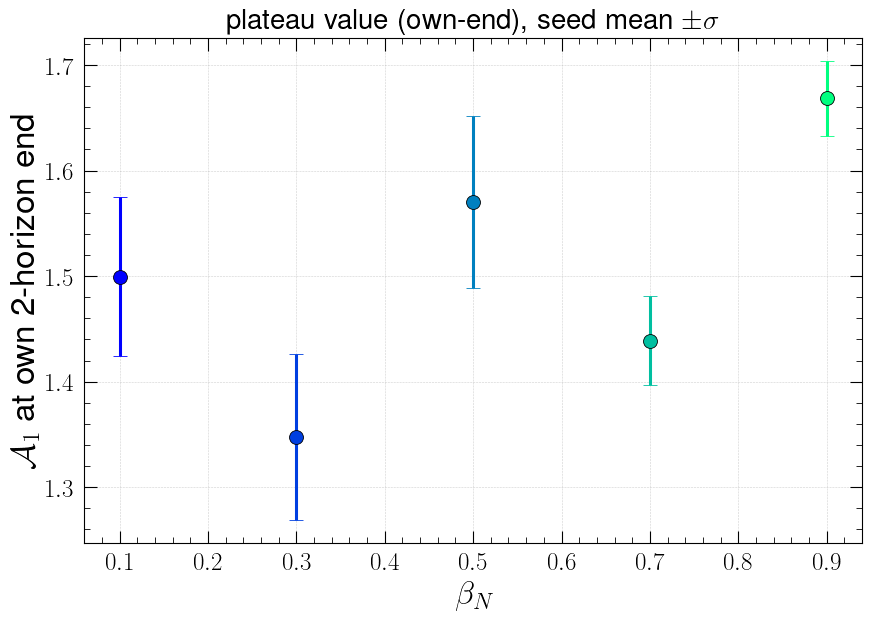

 betaN  n_seeds  eta_end   A1 mean   A1 std
--------------------------------------------
   0.1        5     97.5    1.4995   0.0754
   0.3        5     74.2    1.3471   0.0786
   0.5        5     66.4    1.5704   0.0812
   0.7        5     61.2    1.4389   0.0420
   0.9        5     54.5    1.6685   0.0358


In [66]:
def A_at_own_end(run, frac=0.95):
    eta, A = area_param(run)
    if eta.size < 2:
        return np.nan, np.nan
    sel = eta >= frac * eta[-1]
    if not sel.any():
        sel = np.array([eta.size - 1])
    return float(np.nanmean(A[sel])), float(eta[-1])


plateau_mean, plateau_std, plateau_n, plateau_eta = {}, {}, {}, {}
for b in BETAS:
    vals, ends = [], []
    for r in RUNS.get(b, {}).values():
        v, e = A_at_own_end(r)
        if np.isfinite(v):
            vals.append(v); ends.append(e)
    vals = np.array(vals)
    plateau_mean[b] = np.nanmean(vals) if vals.size else np.nan
    plateau_std[b]  = np.nanstd(vals)  if vals.size else np.nan
    plateau_n[b]    = vals.size
    plateau_eta[b]  = np.mean(ends) if ends else np.nan

fig, ax = plt.subplots(figsize=(9, 6.5))
for b in BETAS:
    ax.errorbar([b], [plateau_mean[b]], yerr=[plateau_std[b]], fmt='o', ms=10,
                color=COLOR[b], ecolor=COLOR[b], capsize=5, lw=2.2, mec='k', mew=0.6)
paper_ax(ax, xlabel=r'$\beta_N$', ylabel=r'$\mathcal{A}_1$ at own 2-horizon end',
         title=r'plateau value (own-end), seed mean $\pm\sigma$')
plt.tight_layout(); plt.show()

print(f"{'betaN':>6s} {'n_seeds':>8s} {'eta_end':>8s} {'A1 mean':>9s} {'A1 std':>8s}")
print('-' * 44)
for b in BETAS:
    print(f"{b:>6.1f} {plateau_n[b]:>8d} {plateau_eta[b]:>8.1f}"
          f" {plateau_mean[b]:>9.4f} {plateau_std[b]:>8.4f}")

## 10. Summary table

Per $\beta$: seeds present, mean formation-onset $\eta$ (turnaround), mean $\langle|\Phi|^2\rangle$ at the
end (compare to the $\mu^2/2=0.00245$ vacuum), and the $\mathcal{A}_1$ own-end plateau and
in-window slope (mean$\pm$std).

In [67]:
def eb_per_seed(b):
    return [breaking_onset_eta(r) for r in RUNS.get(b, {}).values()]

def phi2_end_per_seed(b):
    vals = []
    for r in RUNS.get(b, {}).values():
        eta, p2 = phi2_radial(r)
        if p2.size:
            vals.append(p2[-1])
    return vals

print(f"{'betaN':>6s} {'n':>3s} {'eta_brk':>8s} {'<|Phi|2>_end':>13s} {'(vac=%.4f)'%VAC:>12s}"
      f" {'A1_end':>8s} {'A1_std':>8s} {'slope':>8s} {'slp_std':>8s}")
print('-' * 92)
for b in BETAS:
    ebs = [e for e in eb_per_seed(b) if e is not None]
    eb_mean = np.mean(ebs) if ebs else np.nan
    p2s = phi2_end_per_seed(b)
    p2_mean = np.mean(p2s) if p2s else np.nan
    print(f"{b:>6.1f} {len(RUNS.get(b, {})):>3d} {eb_mean:>8.2f} {p2_mean:>13.5f} {'':>12s}"
          f" {plateau_mean[b]:>8.4f} {plateau_std[b]:>8.4f}"
          f" {slope_mean[b]:>8.4f} {slope_std[b]:>8.4f}")

 betaN   n  eta_brk  <|Phi|2>_end (vac=0.0025)   A1_end   A1_std    slope  slp_std
--------------------------------------------------------------------------------------------
   0.1   5    12.71       0.00244                1.4995   0.0754  -0.2659   0.0420
   0.3   5    13.36       0.00241                1.3471   0.0786  -0.2037   0.0547
   0.5   5    13.80       0.00240                1.5704   0.0812  -0.3488   0.0549
   0.7   5    14.18       0.00240                1.4389   0.0420  -0.3373   0.0428
   0.9   5    13.85       0.00238                1.6685   0.0358  -0.4532   0.0366
